# Aerogel Filtration ML --> Step 1: Exploratory Data Analysis
**Aim:** Understand the dataset before touching any model. Check distributions, missing data, correlations, and outliers.

## 1.1: Install & import libraries

In [27]:
!pip install pandas numpy matplotlib seaborn missingno scipy --quiet

In [28]:
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        
import missingno as msno     
from scipy import stats      
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1.2: Load the dataset

In [29]:
DATA_PATH = 'final_dataset.csv'   
# ─────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH)

# dropping completely empty rows (trailing Excel rows)
df.dropna(how='all', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset loaded: {df.shape[0]} samples, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Dataset loaded: 227 samples, 41 columns
Columns: ['sample_id', 'material_name', 'material_class_original', 'chemical_composition_original', 'architecture_descriptor', 'composition_type_std', 'primary_material_family', 'primary_material_group', 'secondary_material_family', 'secondary_material_group', 'tertiary_material_family', 'tertiary_material_group', 'composition_descriptor_std', 'n_detected_material_families', 'contains_synthetic_polymer', 'contains_inorganic', 'contains_carbonaceous', 'contains_polysaccharide', 'contains_protein', 'contains_fluoropolymer', 'contains_silica', 'contains_mof', 'contains_silver', 'contains_antimicrobial_additive', 'contains_support_substrate', 'is_commercial_reference', 'source', 'solid_content (g/100ml)', 'skeletal_density (g/cm3)', 'porosity (%)', 'permeability (m2)', 'bet_surface_area (m2/g)', 'average_pore_size (nm)', 'fiber_diameter (nm)', 'filtration_efficiency (%)', 'pressure_drop (mmH2O/cm)', 'airflow_rate (cm/s)', 'sample_thickness (mm)', 'av

In [30]:
# quick peek at the first 5 rows
# this lets us to confirm the data loaded correctly
df.head()

,sample_id,material_name,material_class_original,chemical_composition_original,architecture_descriptor,composition_type_std,primary_material_family,primary_material_group,secondary_material_family,secondary_material_group,...,bet_surface_area (m2/g),average_pore_size (nm),fiber_diameter (nm),filtration_efficiency (%),pressure_drop (mmH2O/cm),airflow_rate (cm/s),sample_thickness (mm),average_particle_size (nm),quality_factor (mmH2O^-1),bulk_density (g/cm3)
0,kevlar_aerogel1,kevlar aerogel,kevlar aerogel,PPTA,monolithic_aerogel,synthetic_polymer,kevlar_ppta,synthetic_polymer,NaN,NaN,...,326.0,NaN,32.0,99.500,NaN,50.0,5.00,75.0,NaN,0.016
1,sPS-0.010,sPS aerogel,sPS aerogel,d-form syndiotactic polystyrene,monolithic_aerogel,synthetic_polymer,sps,synthetic_polymer,NaN,NaN,...,NaN,NaN,NaN,93.468,9.7,50.0,3.75,75.0,0.750091,0.020
2,sPS-0.015,sPS aerogel,sPS aerogel,d-form syndiotactic polystyrene,monolithic_aerogel,synthetic_polymer,sps,synthetic_polymer,NaN,NaN,...,NaN,NaN,NaN,95.860,10.1,50.0,3.75,75.0,0.840785,0.025
3,sPS-0.020,sPS aerogel,sPS aerogel,d-form syndiotactic polystyrene,monolithic_aerogel,synthetic_polymer,sps,synthetic_polymer,NaN,NaN,...,NaN,NaN,NaN,98.889,11.6,50.0,3.75,75.0,1.034462,0.030
4,sPS-0.025,sPS aerogel,sPS aerogel,d-form syndiotactic polystyrene,monolithic_aerogel,synthetic_polymer,sps,synthetic_polymer,NaN,NaN,...,NaN,NaN,NaN,99.734,12.3,50.0,3.75,75.0,1.285513,0.034


In [31]:
# data types and non-null counts for every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sample_id                        227 non-null    object 
 1   material_name                    227 non-null    object 
 2   material_class_original          227 non-null    object 
 3   chemical_composition_original    225 non-null    object 
 4   architecture_descriptor          227 non-null    object 
 5   composition_type_std             227 non-null    object 
 6   primary_material_family          225 non-null    object 
 7   primary_material_group           225 non-null    object 
 8   secondary_material_family        110 non-null    object 
 9   secondary_material_group         110 non-null    object 
 10  tertiary_material_family         44 non-null     object 
 11  tertiary_material_group          44 non-null     object 
 12  composition_descriptor

## 1.3: Define which columns are which type

In [32]:
# Numeric measurement columns (the actual physical properties)
NUMERIC_COLS = [
    'solid_content (g/100ml)',
    'skeletal_density (g/cm3)',
    'bulk_density (g/cm3)',
    'porosity (%)',
    'permeability (m2)',
    'bet_surface_area (m2/g)',
    'average_pore_size (nm)',
    'fiber_diameter (nm)',
    'airflow_rate (cm/s)',
    'sample_thickness (mm)',
    'average_particle_size (nm)',
]

# Target variables (what we want to predict) 
TARGET_FILTRATION = 'filtration_efficiency (%)'
TARGET_QF         = 'quality_factor (mmH2O^-1)'
TARGETS = [TARGET_FILTRATION, TARGET_QF]

# Categorical columns (text labels) 
CATEGORICAL_COLS = [
    'architecture_descriptor',
    'composition_type_std',
    'primary_material_family',
    'primary_material_group',
    'secondary_material_family',
    'secondary_material_group',
    'tertiary_material_family',
    'tertiary_material_group',
    'composition_descriptor_std',
]

# Binary flags (0 or 1) 
BINARY_COLS = [
    'contains_synthetic_polymer',
    'contains_inorganic',
    'contains_carbonaceous',
    'contains_polysaccharide',
    'contains_protein',
    'contains_fluoropolymer',
    'contains_silica',
    'contains_mof',
    'contains_silver',
    'contains_antimicrobial_additive',
    'contains_support_substrate',
    'is_commercial_reference',
]


NUMERIC_COLS    = [c for c in NUMERIC_COLS    if c in df.columns]
CATEGORICAL_COLS= [c for c in CATEGORICAL_COLS if c in df.columns]
BINARY_COLS     = [c for c in BINARY_COLS     if c in df.columns]

print('Numeric columns found:',    len(NUMERIC_COLS))
print('Categorical columns found:', len(CATEGORICAL_COLS))
print('Binary columns found:',     len(BINARY_COLS))

Numeric columns found: 11
Categorical columns found: 9
Binary columns found: 12


## 1.4: Missing data overview

In [33]:
# count and percentage of missing values per column
# sorted from most missing to least
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct':   (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)

# just show columns that have at least 1 missing value
missing = missing[missing['missing_count'] > 0]
print(missing.to_string())

                               missing_count  missing_pct
tertiary_material_group                  183         80.6
tertiary_material_family                 183         80.6
skeletal_density (g/cm3)                 160         70.5
permeability (m2)                        160         70.5
quality_factor (mmH2O^-1)                145         63.9
fiber_diameter (nm)                      143         63.0
average_pore_size (nm)                   142         62.6
bet_surface_area (m2/g)                  141         62.1
porosity (%)                             136         59.9
pressure_drop (mmH2O/cm)                 124         54.6
solid_content (g/100ml)                  120         52.9
secondary_material_group                 117         51.5
secondary_material_family                117         51.5
bulk_density (g/cm3)                     112         49.3
sample_thickness (mm)                     96         42.3
airflow_rate (cm/s)                       58         25.6
filtration_eff

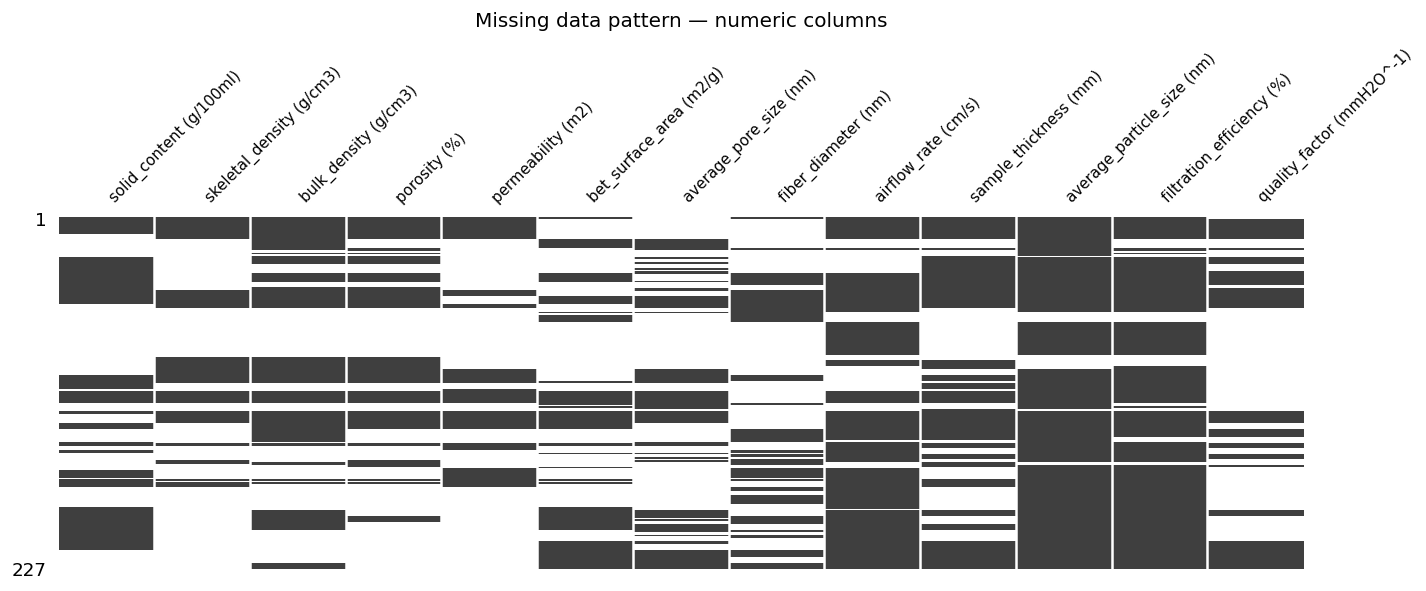

Saved: missing_data_matrix.png


In [34]:
# visual missing data matrix
# WHITE = data present, BLACK = missing

cols_to_show = NUMERIC_COLS + TARGETS
cols_to_show = [c for c in cols_to_show if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df[cols_to_show], ax=ax, sparkline=False, fontsize=9)
ax.set_title('Missing data pattern — numeric columns', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('missing_data_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: missing_data_matrix.png')

In [35]:
# How many samples have BOTH targets available?
n_filtration = df[TARGET_FILTRATION].notna().sum()
n_qf         = df[TARGET_QF].notna().sum()
n_both       = df[TARGETS].dropna().shape[0]

print(f'Samples with filtration_efficiency:  {n_filtration} / {len(df)}')
print(f'Samples with quality_factor:         {n_qf} / {len(df)}')
print(f'Samples with BOTH targets:           {n_both} / {len(df)}')
print()
print('>>> Your primary model (filtration efficiency) will use', n_filtration, 'samples')
print('>>> Your secondary model (quality factor) will use', n_qf, 'samples')

Samples with filtration_efficiency:  195 / 227
Samples with quality_factor:         82 / 227
Samples with BOTH targets:           82 / 227

>>> Your primary model (filtration efficiency) will use 195 samples
>>> Your secondary model (quality factor) will use 82 samples


## 1.5: Target variable distributions

--- Filtration efficiency (%) ---
count    195.000
mean      89.963
std       20.291
min        0.000
25%       91.000
50%       98.889
75%       99.900
max      100.000
Name: filtration_efficiency (%), dtype: float64
Skewness: -2.927 ⚠ Consider log-transform

--- Quality factor (mmH2O⁻¹) ---
count     82.000
mean       5.173
std       23.949
min        0.000
25%        0.238
50%        0.354
75%        0.805
max      189.421
Name: quality_factor (mmH2O^-1), dtype: float64
Skewness: 6.445 ⚠ Consider log-transform



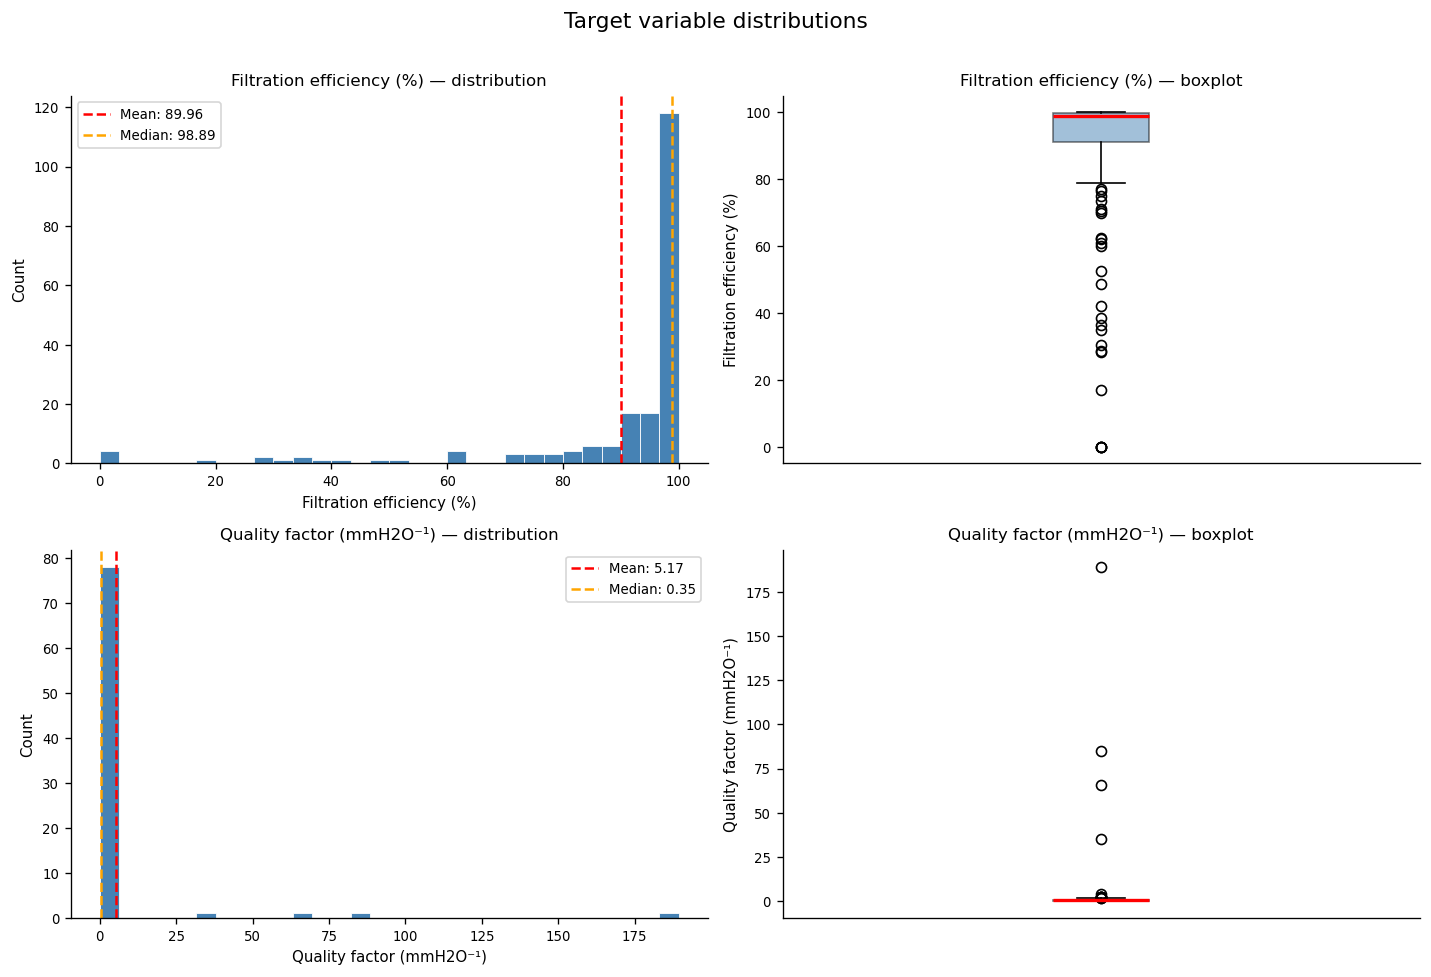

Saved: target_distributions.png


In [36]:
# If filtration efficiency is heavily skewed (most values near 99%),
# we will need to transform it (like log-transform) before modeling.

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (target, label) in enumerate([
    (TARGET_FILTRATION, 'Filtration efficiency (%)'),
    (TARGET_QF,         'Quality factor (mmH2O⁻¹)')
]):
    data = df[target].dropna()

    # Histogram
    ax = axes[i, 0]
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.2f}')
    ax.set_title(f'{label} — distribution')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    # box plot — shows outliers as individual dots
    ax = axes[i, 1]
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{label} — boxplot')
    ax.set_ylabel(label)
    ax.set_xticks([])

    # Print summary stats
    print(f'--- {label} ---')
    print(data.describe().round(3))

    # Skewness test: if |skew| > 1, consider log-transforming
    skew = data.skew()
    print(f'Skewness: {skew:.3f}', '⚠ Consider log-transform' if abs(skew) > 1 else '✓ Roughly symmetric')
    print()

plt.suptitle('Target variable distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('target_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: target_distributions.png')

## 1.6: Feature distributions

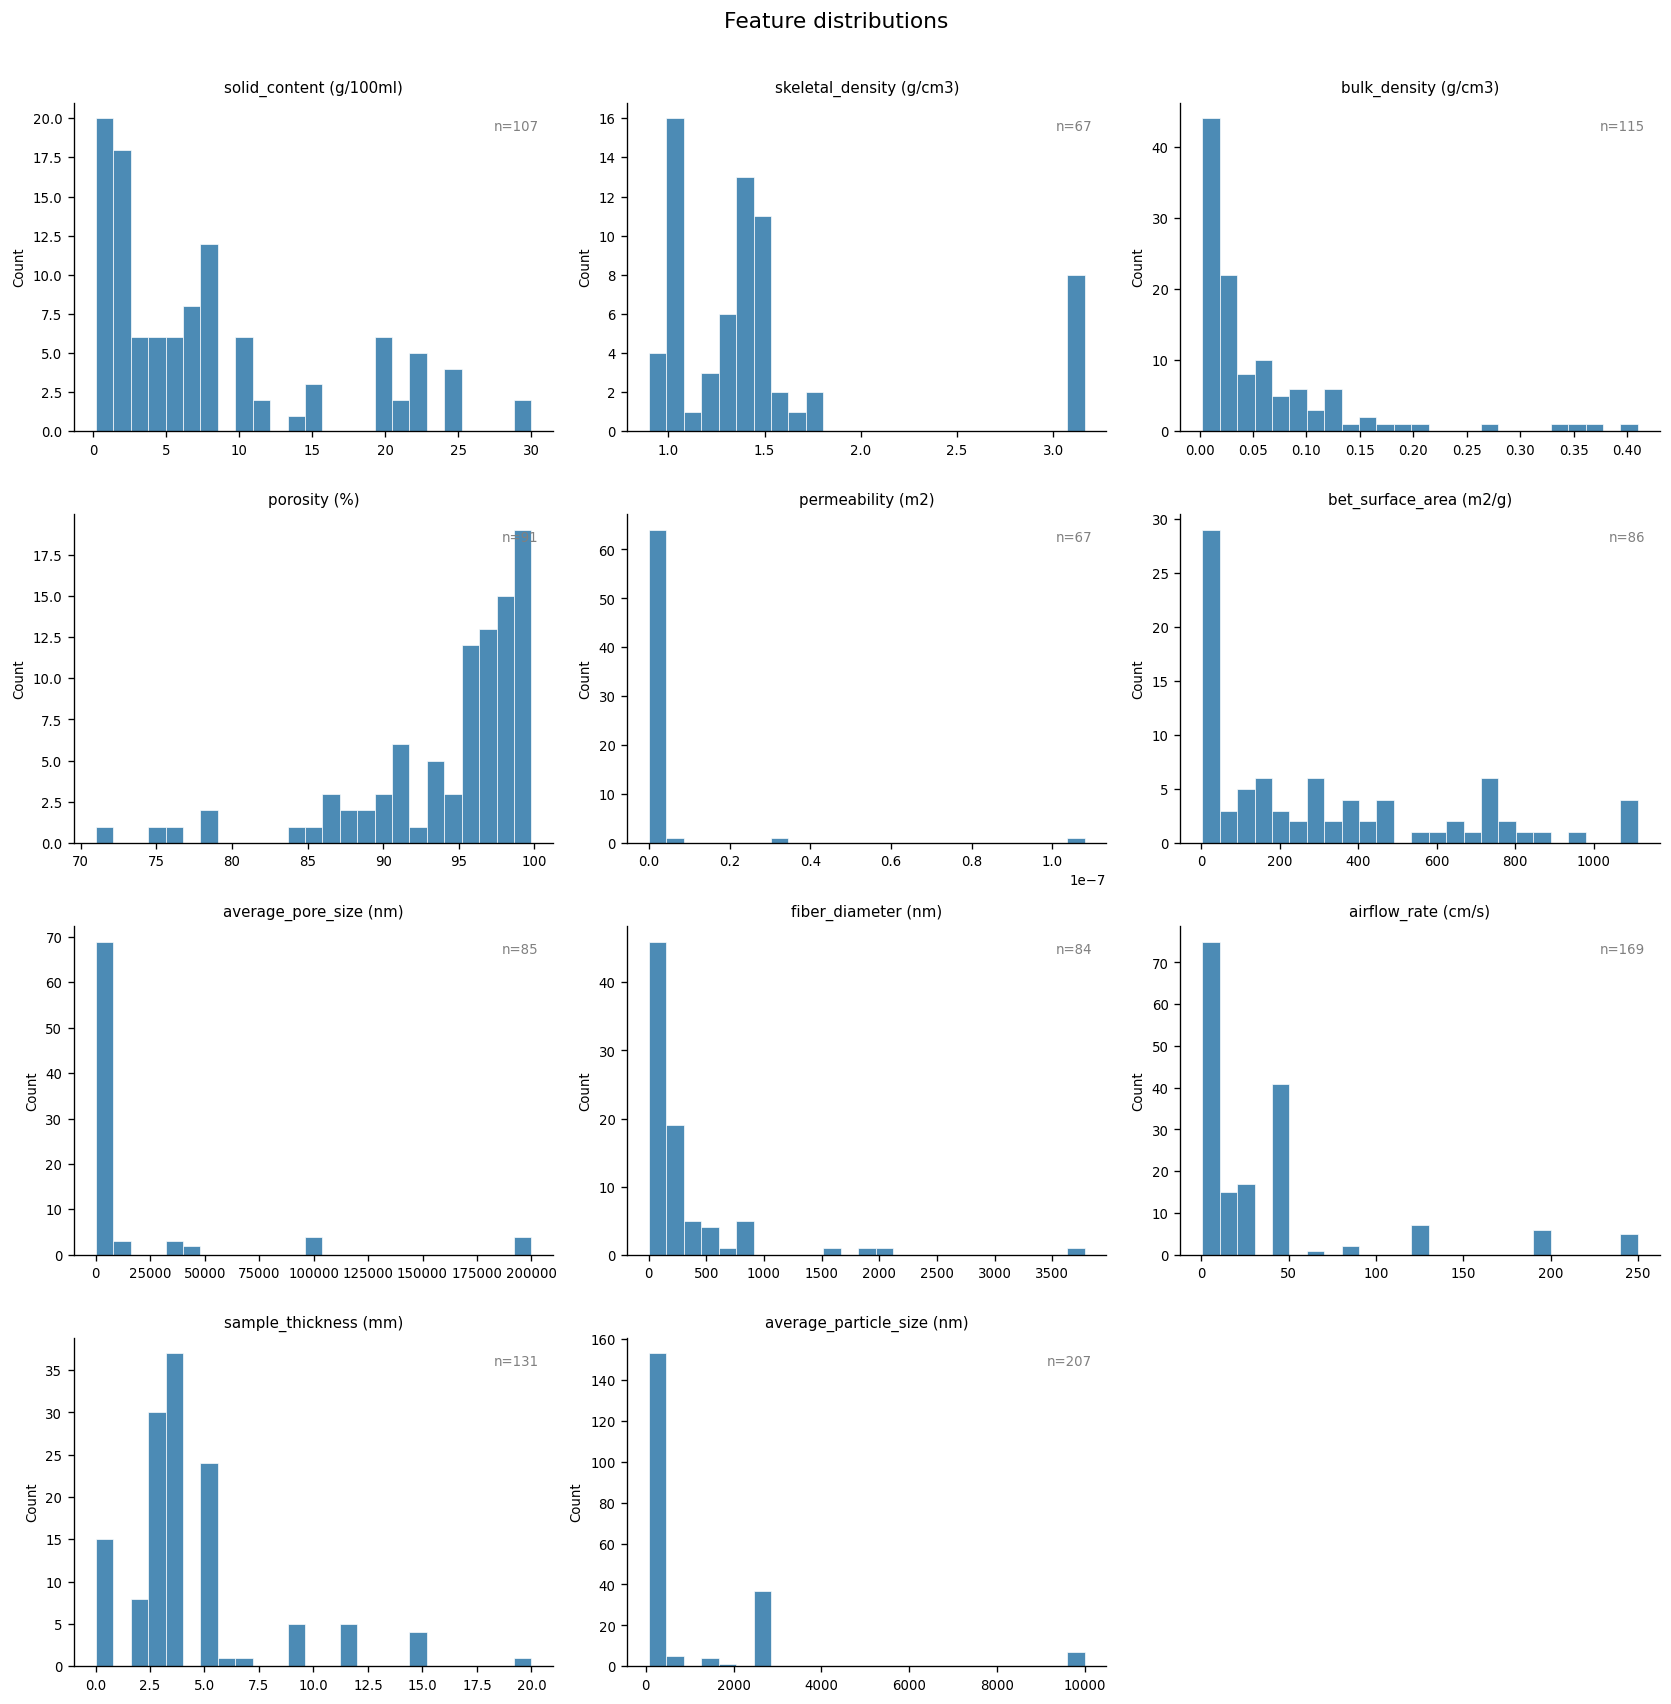

Saved: feature_distributions.png


In [37]:
# Distribution of every numeric feature
# Look for: extreme outliers, columns that are near-constant,
# or columns where all values are the same (those are useless for ML)

n_cols = len(NUMERIC_COLS)
n_rows = (n_cols + 2) // 3  # 3 plots per row

fig, axes = plt.subplots(n_rows, 3, figsize=(14, n_rows * 3.5))
axes = axes.flatten()  # makes it easier to index

for i, col in enumerate(NUMERIC_COLS):
    data = df[col].dropna()
    ax = axes[i]
    ax.hist(data, bins=25, color='#4C8BB5', edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=8)
    n_valid = len(data)
    ax.text(0.97, 0.95, f'n={n_valid}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

## 1.7: Correlation matrix

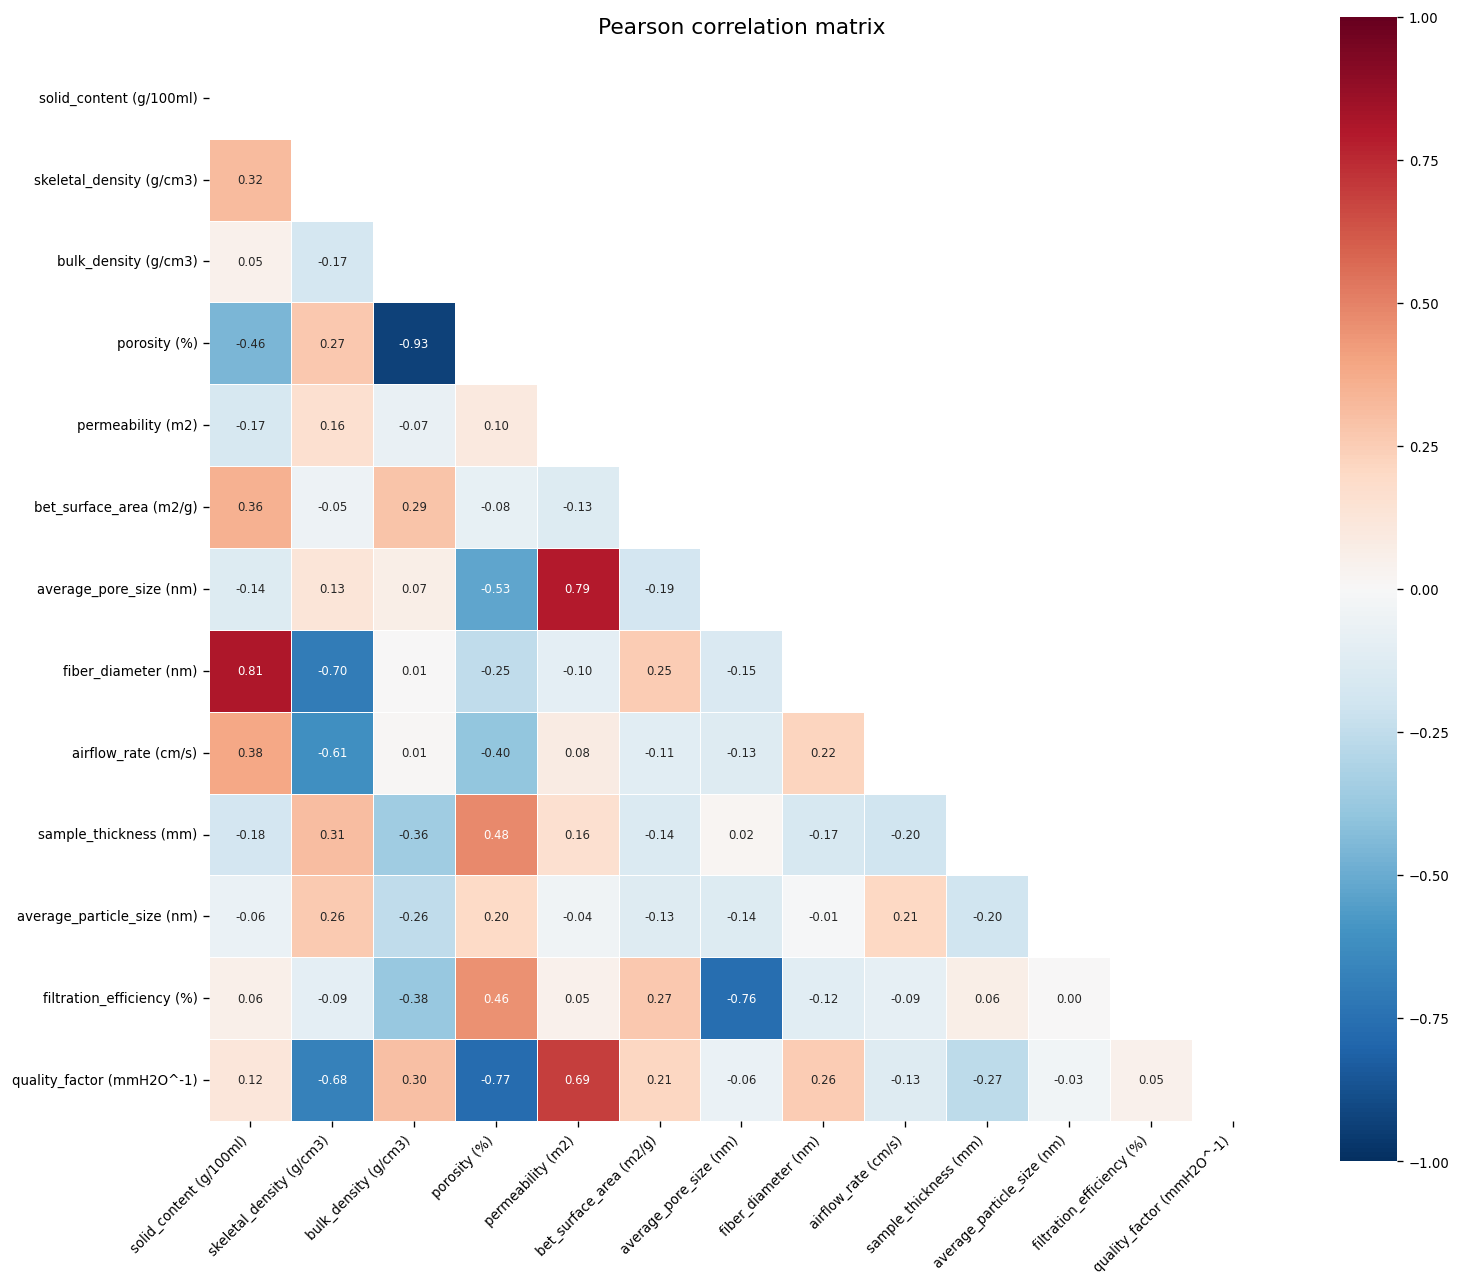

Saved: correlation_matrix.png


In [38]:
# Pearson correlation between all numeric features + targets
# RED = strong positive, BLUE = strong negative
# Wwtching for for pairs with |r| > 0.90 — those are collinear and one should be dropped

corr_cols = NUMERIC_COLS + TARGETS
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # for only showing lower triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # show numbers in each cell
    fmt='.2f',           # 2 decimal places
    cmap='RdBu_r',       # red=positive, blue=negative
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Pearson correlation matrix', fontsize=13, pad=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: correlation_matrix.png')

In [39]:
# Print which pairs have |correlation| > 0.80
# These are candidates to drop one of (collinearity)
print('Highly correlated feature pairs (|r| > 0.80):')
print('-' * 55)

found_any = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.80:
            col_a = corr_matrix.columns[i]
            col_b = corr_matrix.columns[j]
            print(f'  {col_a}  <-->  {col_b}   r = {r:.3f}')
            found_any = True

if not found_any:
    print('  None found — no major collinearity issues.')

Highly correlated feature pairs (|r| > 0.80):
-------------------------------------------------------
  solid_content (g/100ml)  <-->  fiber_diameter (nm)   r = 0.810
  bulk_density (g/cm3)  <-->  porosity (%)   r = -0.935


## 1.8: Material class breakdown

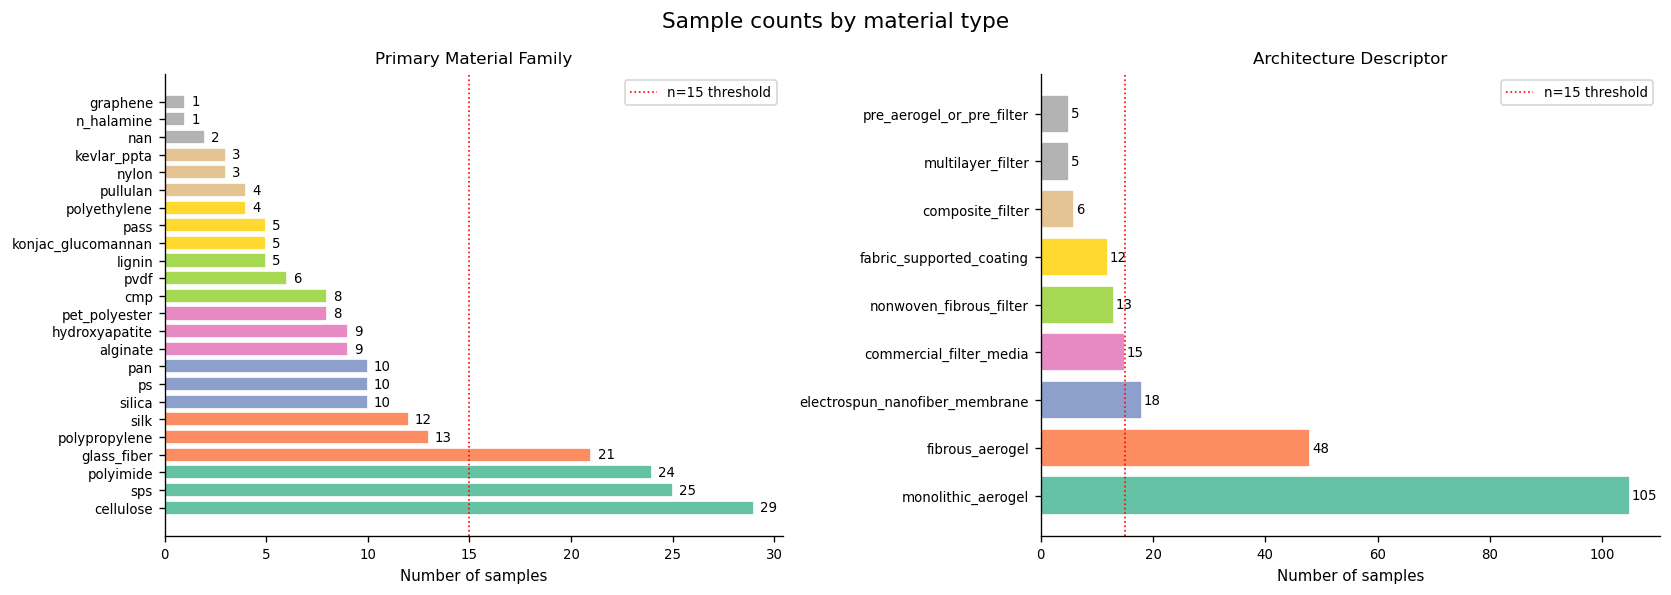

Saved: material_class_counts.png


In [40]:
# How many samples per material class and architecture?
# Important for knowing whether subgroup analyses are feasible

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['primary_material_family', 'architecture_descriptor']):
    if col not in df.columns:
        continue
    counts = df[col].value_counts(dropna=False)
    colors = plt.cm.Set2(np.linspace(0, 1, len(counts)))
    bars = ax.barh(counts.index.astype(str), counts.values, color=colors, edgecolor='white')
    ax.set_xlabel('Number of samples')
    ax.set_title(col.replace('_', ' ').title())
    # Add count labels on bars
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)
    ax.axvline(15, color='red', linestyle=':', linewidth=1, label='n=15 threshold')
    ax.legend(fontsize=8)

plt.suptitle('Sample counts by material type', fontsize=13)
plt.tight_layout()
plt.savefig('material_class_counts.png', bbox_inches='tight')
plt.show()
print('Saved: material_class_counts.png')

## 1.9: Target vs each feature (scatter plots)

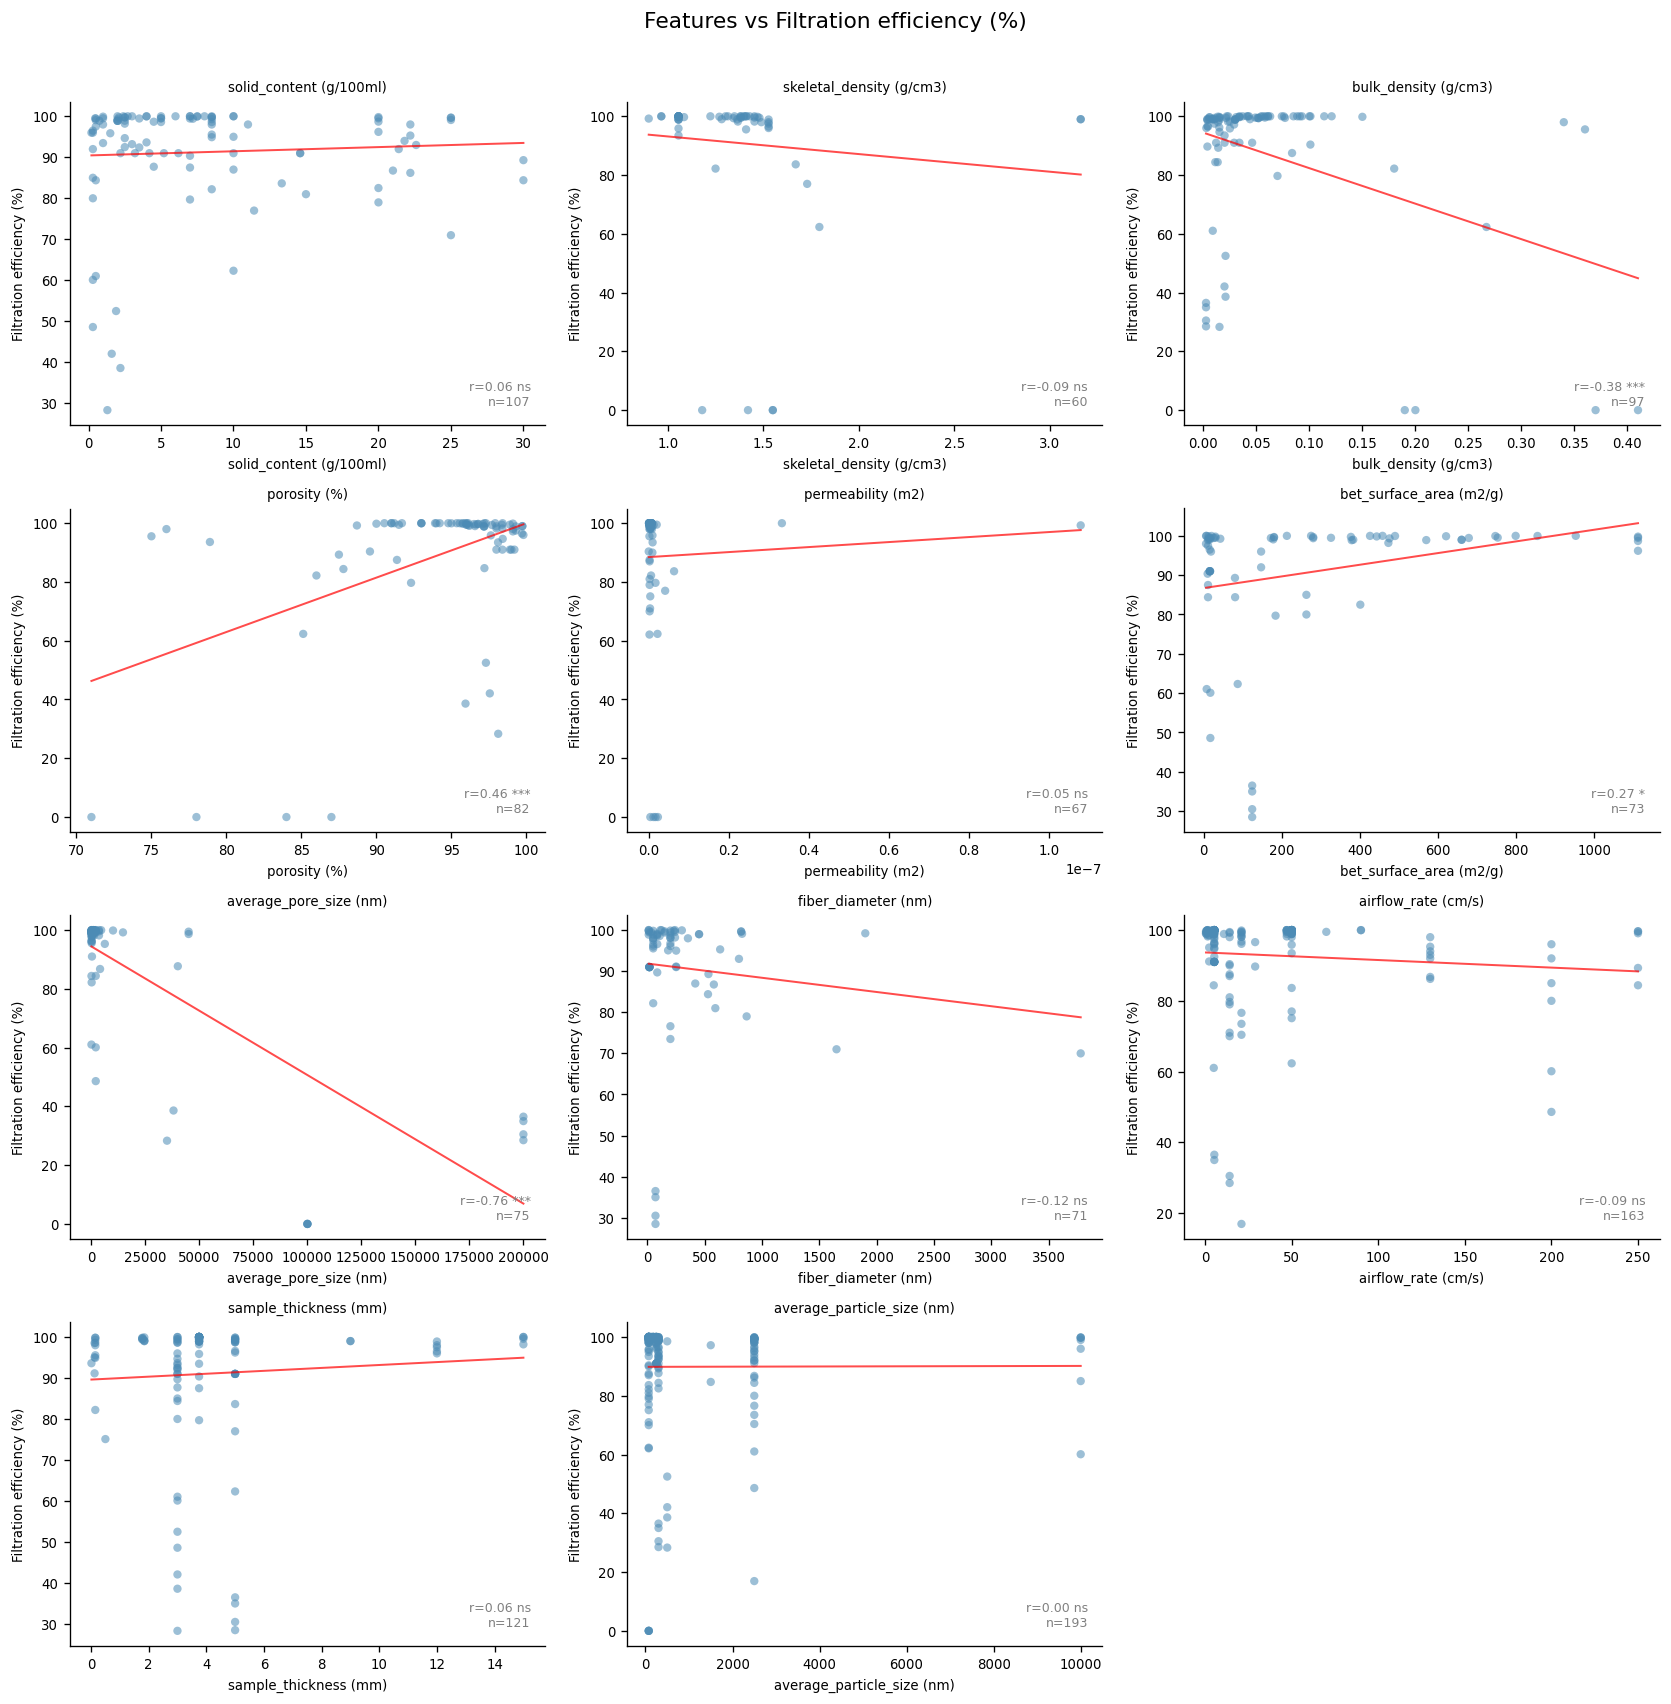

Saved: scatter_vs_filtration.png


In [41]:
# Scatter plot of each numeric feature vs filtration efficiency
# This is a first visual check for relationships before any model
# looking for: clear trends (linear or curved), obvious outliers,
# or features that look completely random 

def plot_feature_vs_target(target_col, target_label, filename):
    data = df[df[target_col].notna()].copy()
    features = [c for c in NUMERIC_COLS if c != target_col and data[c].notna().sum() > 20]

    n_cols = 3
    n_rows = (len(features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        subset = data[[feat, target_col]].dropna()
        ax.scatter(subset[feat], subset[target_col],
                   alpha=0.55, s=25, color='#4C8BB5', edgecolors='none')

        # Add a trend line (linear regression)
        if len(subset) > 5:
            m, b, r, p, _ = stats.linregress(subset[feat], subset[target_col])
            x_line = np.linspace(subset[feat].min(), subset[feat].max(), 100)
            ax.plot(x_line, m * x_line + b, color='red', linewidth=1.2, alpha=0.7)
            # Show r and p-value
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            ax.text(0.97, 0.05, f'r={r:.2f} {sig}\nn={len(subset)}',
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=7.5, color='gray')

        ax.set_xlabel(feat, fontsize=8)
        ax.set_ylabel(target_label, fontsize=8)
        ax.set_title(feat, fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Features vs {target_label}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

# Plot for filtration efficiency
plot_feature_vs_target(
    TARGET_FILTRATION,
    'Filtration efficiency (%)',
    'scatter_vs_filtration.png'
)

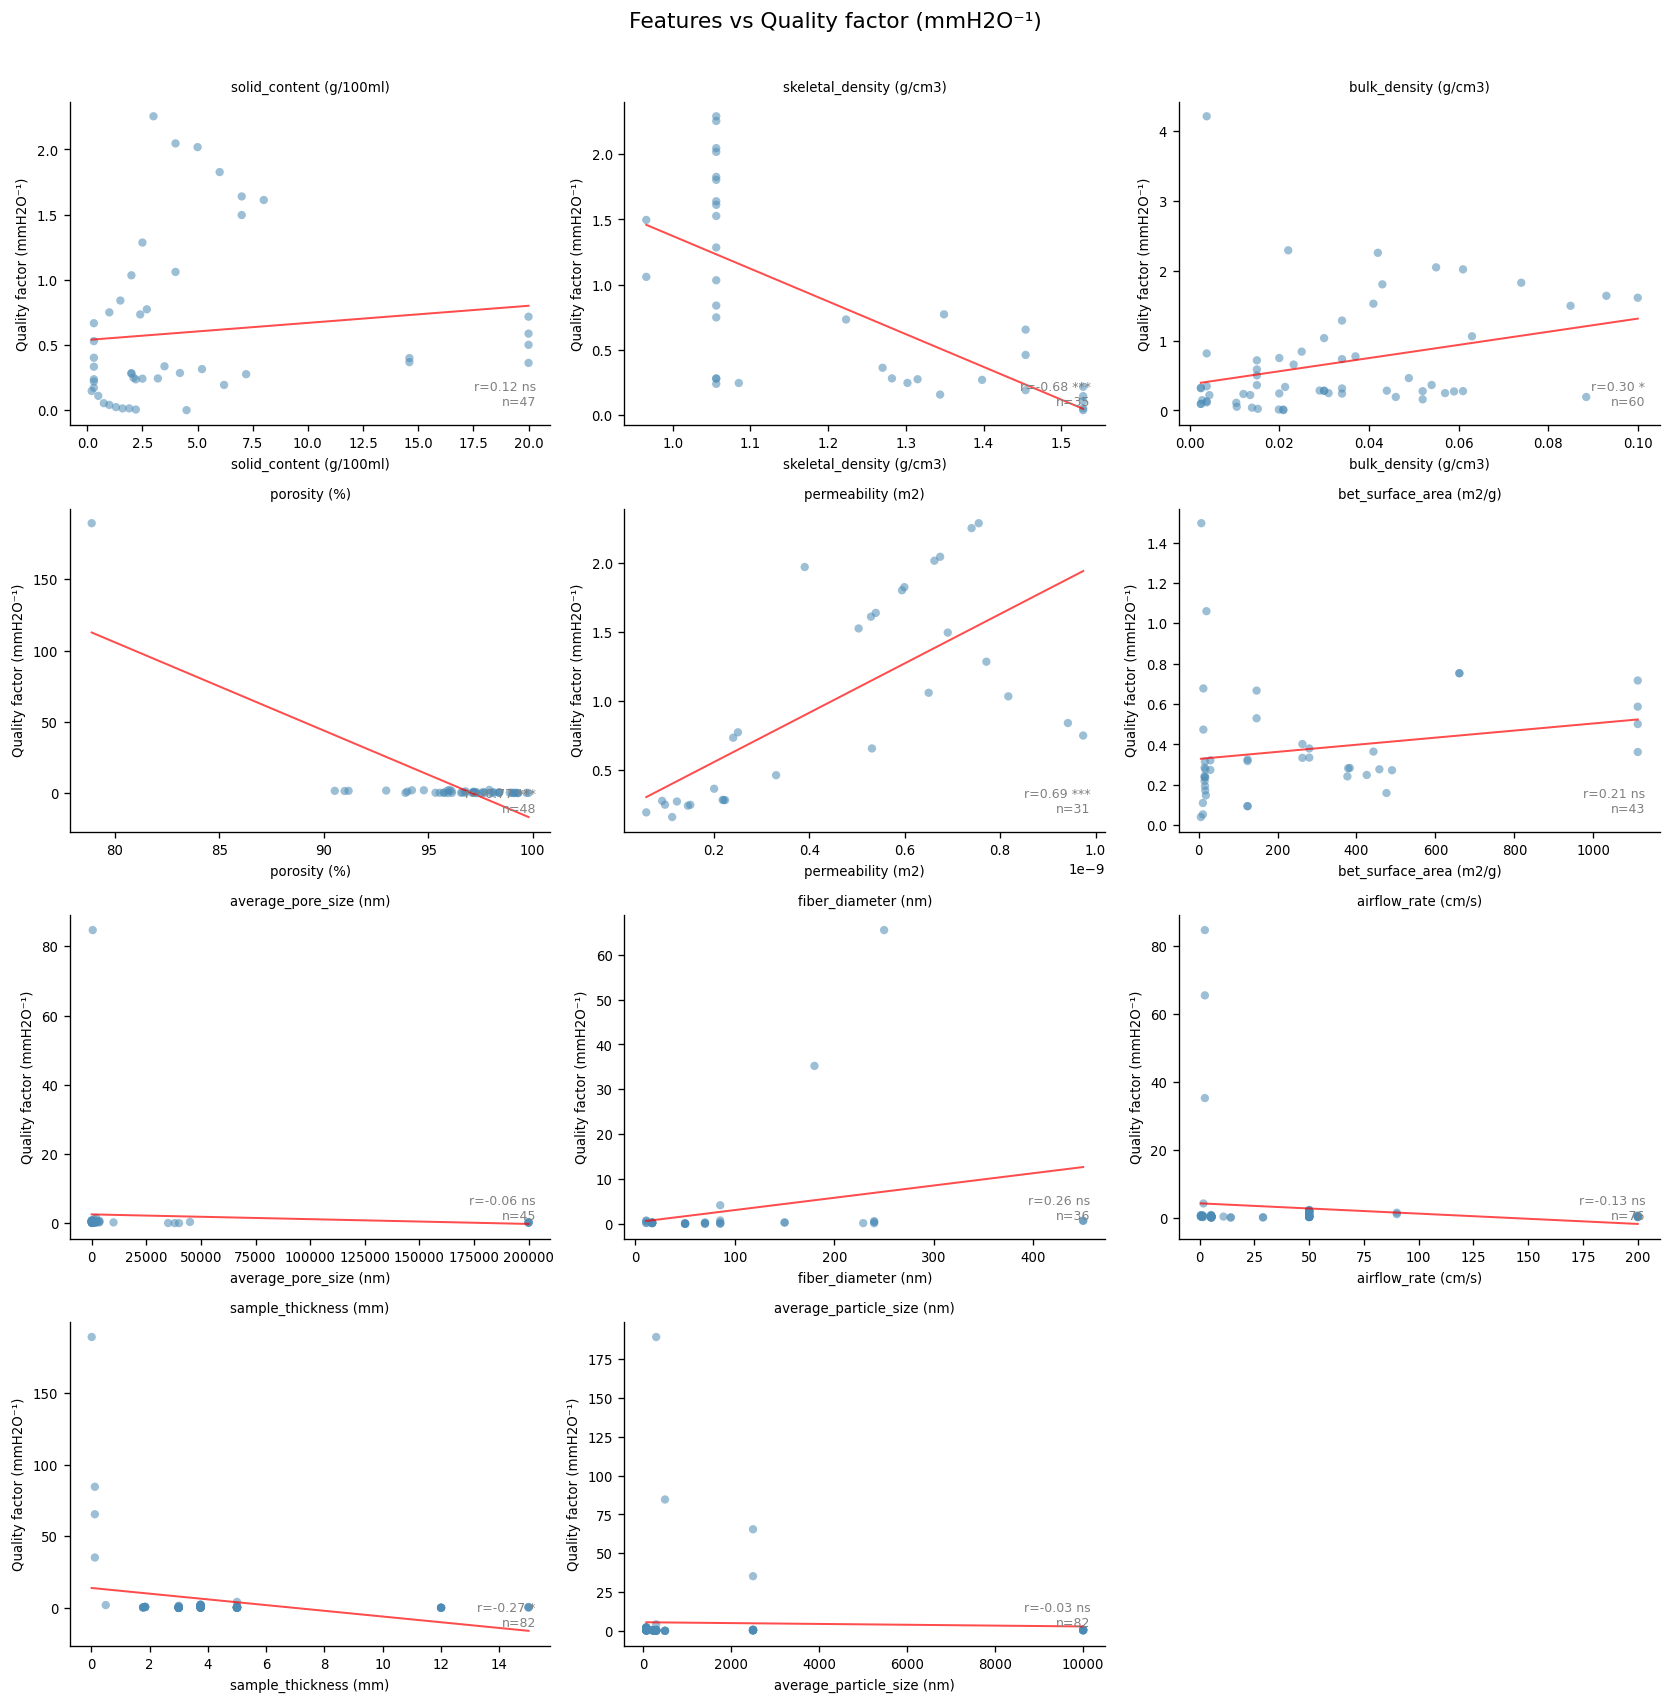

Saved: scatter_vs_qualityfactor.png


In [42]:
# Same scatter plots but for quality factor
plot_feature_vs_target(
    TARGET_QF,
    'Quality factor (mmH2O⁻¹)',
    'scatter_vs_qualityfactor.png'
)

## 1.10: Target vs categorical features (box plots)

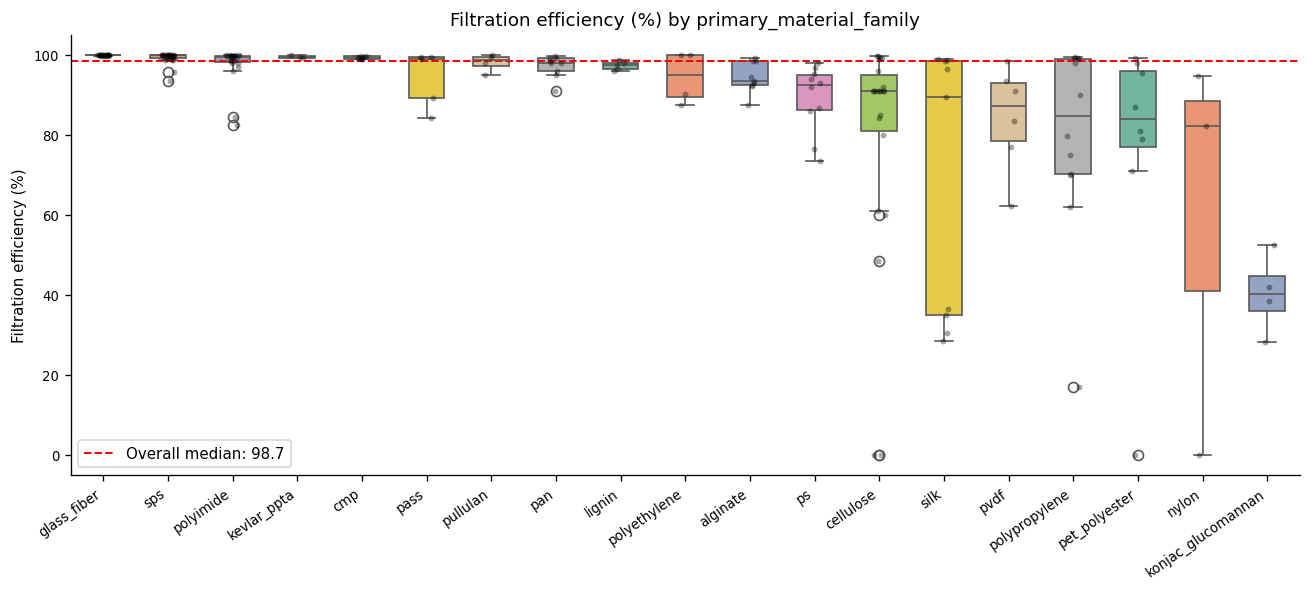

Saved: boxplot_family_vs_filtration.png


In [43]:
# Do different material families have different filtration efficiencies?
# Box plots show median + spread per group
# Red dashed line = overall median across all samples

def plot_target_by_category(cat_col, target_col, target_label, filename):
    if cat_col not in df.columns:
        print(f'Column {cat_col} not found, skipping.')
        return
    data = df[[cat_col, target_col]].dropna()
    if data.empty:
        print(f'No data for {cat_col} vs {target_col}')
        return

    # Only keep groups with at least 3 samples
    counts = data[cat_col].value_counts()
    valid_groups = counts[counts >= 3].index
    data = data[data[cat_col].isin(valid_groups)]

    order = data.groupby(cat_col)[target_col].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=data, x=cat_col, y=target_col, order=order,
                palette='Set2', width=0.55, ax=ax)
    sns.stripplot(data=data, x=cat_col, y=target_col, order=order,
                  color='black', alpha=0.35, size=3.5, ax=ax, jitter=True)

    overall_median = data[target_col].median()
    ax.axhline(overall_median, color='red', linestyle='--',
               linewidth=1.2, label=f'Overall median: {overall_median:.1f}')

    ax.set_title(f'{target_label} by {cat_col}', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(target_label)
    ax.legend(fontsize=9)
    plt.xticks(rotation=35, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

# Filtration efficiency by primary material family
plot_target_by_category(
    'primary_material_family',
    TARGET_FILTRATION,
    'Filtration efficiency (%)',
    'boxplot_family_vs_filtration.png'
)

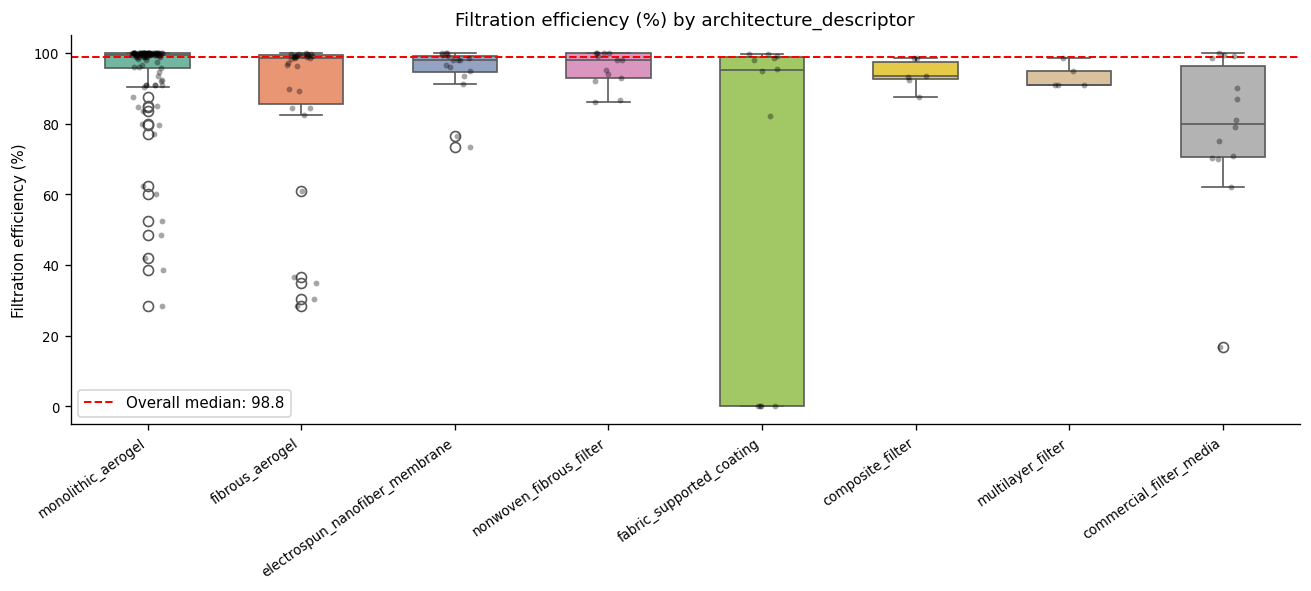

Saved: boxplot_architecture_vs_filtration.png


In [44]:
# Filtration efficiency by architecture
plot_target_by_category(
    'architecture_descriptor',
    TARGET_FILTRATION,
    'Filtration efficiency (%)',
    'boxplot_architecture_vs_filtration.png'
)

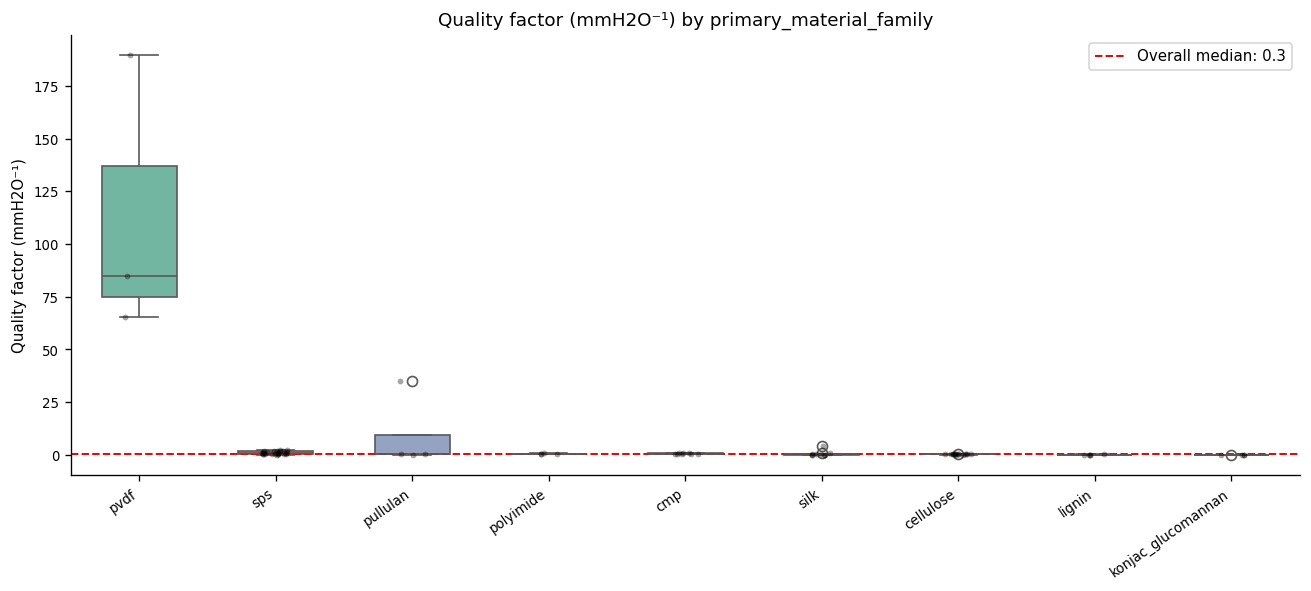

Saved: boxplot_family_vs_qf.png


In [45]:
# Quality factor by primary material family
plot_target_by_category(
    'primary_material_family',
    TARGET_QF,
    'Quality factor (mmH2O⁻¹)',
    'boxplot_family_vs_qf.png'
)

## 1.11: Binary flag analysis

In [46]:
# For each binary flag (contains_silica, contains_mof, etc.)
# compare the filtration efficiency of samples where flag=1 vs flag=0
# this gives an early hint of which composition traits matter

print(f'Binary flag comparison — {TARGET_FILTRATION}')
print('=' * 65)
print(f'{"Flag":<35} {"n(=1)":>6} {"Median(=1)":>11} {"Median(=0)":>11} {"p-value":>9}')
print('-' * 65)

results = []
for flag in BINARY_COLS:
    if flag not in df.columns: continue
    sub = df[[flag, TARGET_FILTRATION]].dropna()
    if sub.empty: continue
    group1 = sub[sub[flag] == 1][TARGET_FILTRATION]
    group0 = sub[sub[flag] == 0][TARGET_FILTRATION]
    if len(group1) < 3 or len(group0) < 3: continue
    # Mann-Whitney U test (non-parametric, does not assume normal distribution)
    stat, p = stats.mannwhitneyu(group1, group0, alternative='two-sided')
    sig = ' ***' if p < 0.001 else ' **' if p < 0.01 else ' *' if p < 0.05 else ''
    print(f'{flag:<35} {len(group1):>6} {group1.median():>11.2f} {group0.median():>11.2f} {p:>9.4f}{sig}')
    results.append({'flag': flag, 'n_positive': len(group1),
                    'median_pos': group1.median(), 'median_neg': group0.median(), 'p': p})

print()
print('* p<0.05  ** p<0.01  *** p<0.001')
print('Significant flags suggest that composition trait influences filtration efficiency.')

Binary flag comparison — filtration_efficiency (%)
Flag                                 n(=1)  Median(=1)  Median(=0)   p-value
-----------------------------------------------------------------
contains_synthetic_polymer             114       98.64       99.00    0.5104
contains_inorganic                      61       99.80       97.59    0.0000 ***
contains_carbonaceous                   15       99.00       98.70    0.9336
contains_polysaccharide                 64       98.10       98.92    0.8435
contains_protein                        19       91.00       98.96    0.0037 **
contains_fluoropolymer                   9       93.60       98.89    0.5312
contains_silica                         36       99.98       98.00    0.0000 ***
contains_mof                            10       97.45       98.89    0.7603
contains_silver                         12       98.94       98.89    0.9937
contains_antimicrobial_additive         14       98.94       98.89    0.8344
contains_support_substrat

## 1.12: EDA Summary

In [47]:
# Summary statistics table for all numeric columns

summary = df[NUMERIC_COLS + TARGETS].describe().T
summary.insert(0, 'non_null', df[NUMERIC_COLS + TARGETS].notna().sum())
summary.insert(1, 'missing_pct', (df[NUMERIC_COLS + TARGETS].isnull().sum() / len(df) * 100).round(1))
summary = summary.round(3)

print('Summary statistics (save this for Table 1 in your paper):')
print(summary[['non_null','missing_pct','mean','std','min','25%','50%','75%','max']].to_string())

# Save to CSV
summary.to_csv('table1_summary_statistics.csv')
print('\nSaved: table1_summary_statistics.csv')

Summary statistics (save this for Table 1 in your paper):
                            non_null  missing_pct       mean        std     min      25%       50%       75%         max
solid_content (g/100ml)          107         52.9      7.979      7.870   0.200    2.000     5.000    10.000      30.000
skeletal_density (g/cm3)          67         70.5      1.513      0.646   0.900    1.056     1.381     1.528       3.163
bulk_density (g/cm3)             115         49.3      0.058      0.078   0.002    0.011     0.030     0.075       0.410
porosity (%)                      91         59.9     94.437      6.002  71.000   92.005    96.570    98.400      99.800
permeability (m2)                 67         70.5      0.000      0.000   0.000    0.000     0.000     0.000       0.000
bet_surface_area (m2/g)           86         62.1    307.673    322.973   2.670   17.045   182.000   475.250    1112.400
average_pore_size (nm)            85         62.6  17858.510  46541.207   2.000  100.000  1000.

In [48]:
# Final checklist before moving to Step 2
print('EDA CHECKLIST')
print('=' * 50)
checks = [
    ('Empty rows dropped',               df['sample_id'].notna().all() if 'sample_id' in df.columns else True),
    ('Target 1 has enough samples (>50)', df[TARGET_FILTRATION].notna().sum() > 50),
    ('Target 2 has enough samples (>50)', df[TARGET_QF].notna().sum() > 50),
    ('No column is 100% missing',         df.isnull().all().sum() == 0),
]
for label, passed in checks:
    status = 'PASS' if passed else 'FAIL — review before continuing'
    print(f'  [{status}] {label}')

print()
print('When all checks pass, proceed to Step 2 — preprocessing and encoding.')

EDA CHECKLIST
  [PASS] Empty rows dropped
  [PASS] Target 1 has enough samples (>50)
  [PASS] Target 2 has enough samples (>50)
  [PASS] No column is 100% missing

When all checks pass, proceed to Step 2 — preprocessing and encoding.


In [49]:
print(df['permeability (m2)'].describe())
print(df['permeability (m2)'].value_counts().head(10))

count    6.700000e+01
mean     2.767187e-09
std      1.368009e-08
min      6.110000e-12
25%      2.175000e-10
50%      3.400000e-10
75%      7.630000e-10
max      1.080000e-07
Name: permeability (m2), dtype: float64
permeability (m2)
2.300000e-10    4
1.960000e-10    2
1.800000e-10    2
1.700000e-09    2
9.100000e-11    1
4.120000e-10    1
3.370000e-10    1
3.030000e-10    1
2.430000e-10    1
2.230000e-10    1
Name: count, dtype: int64


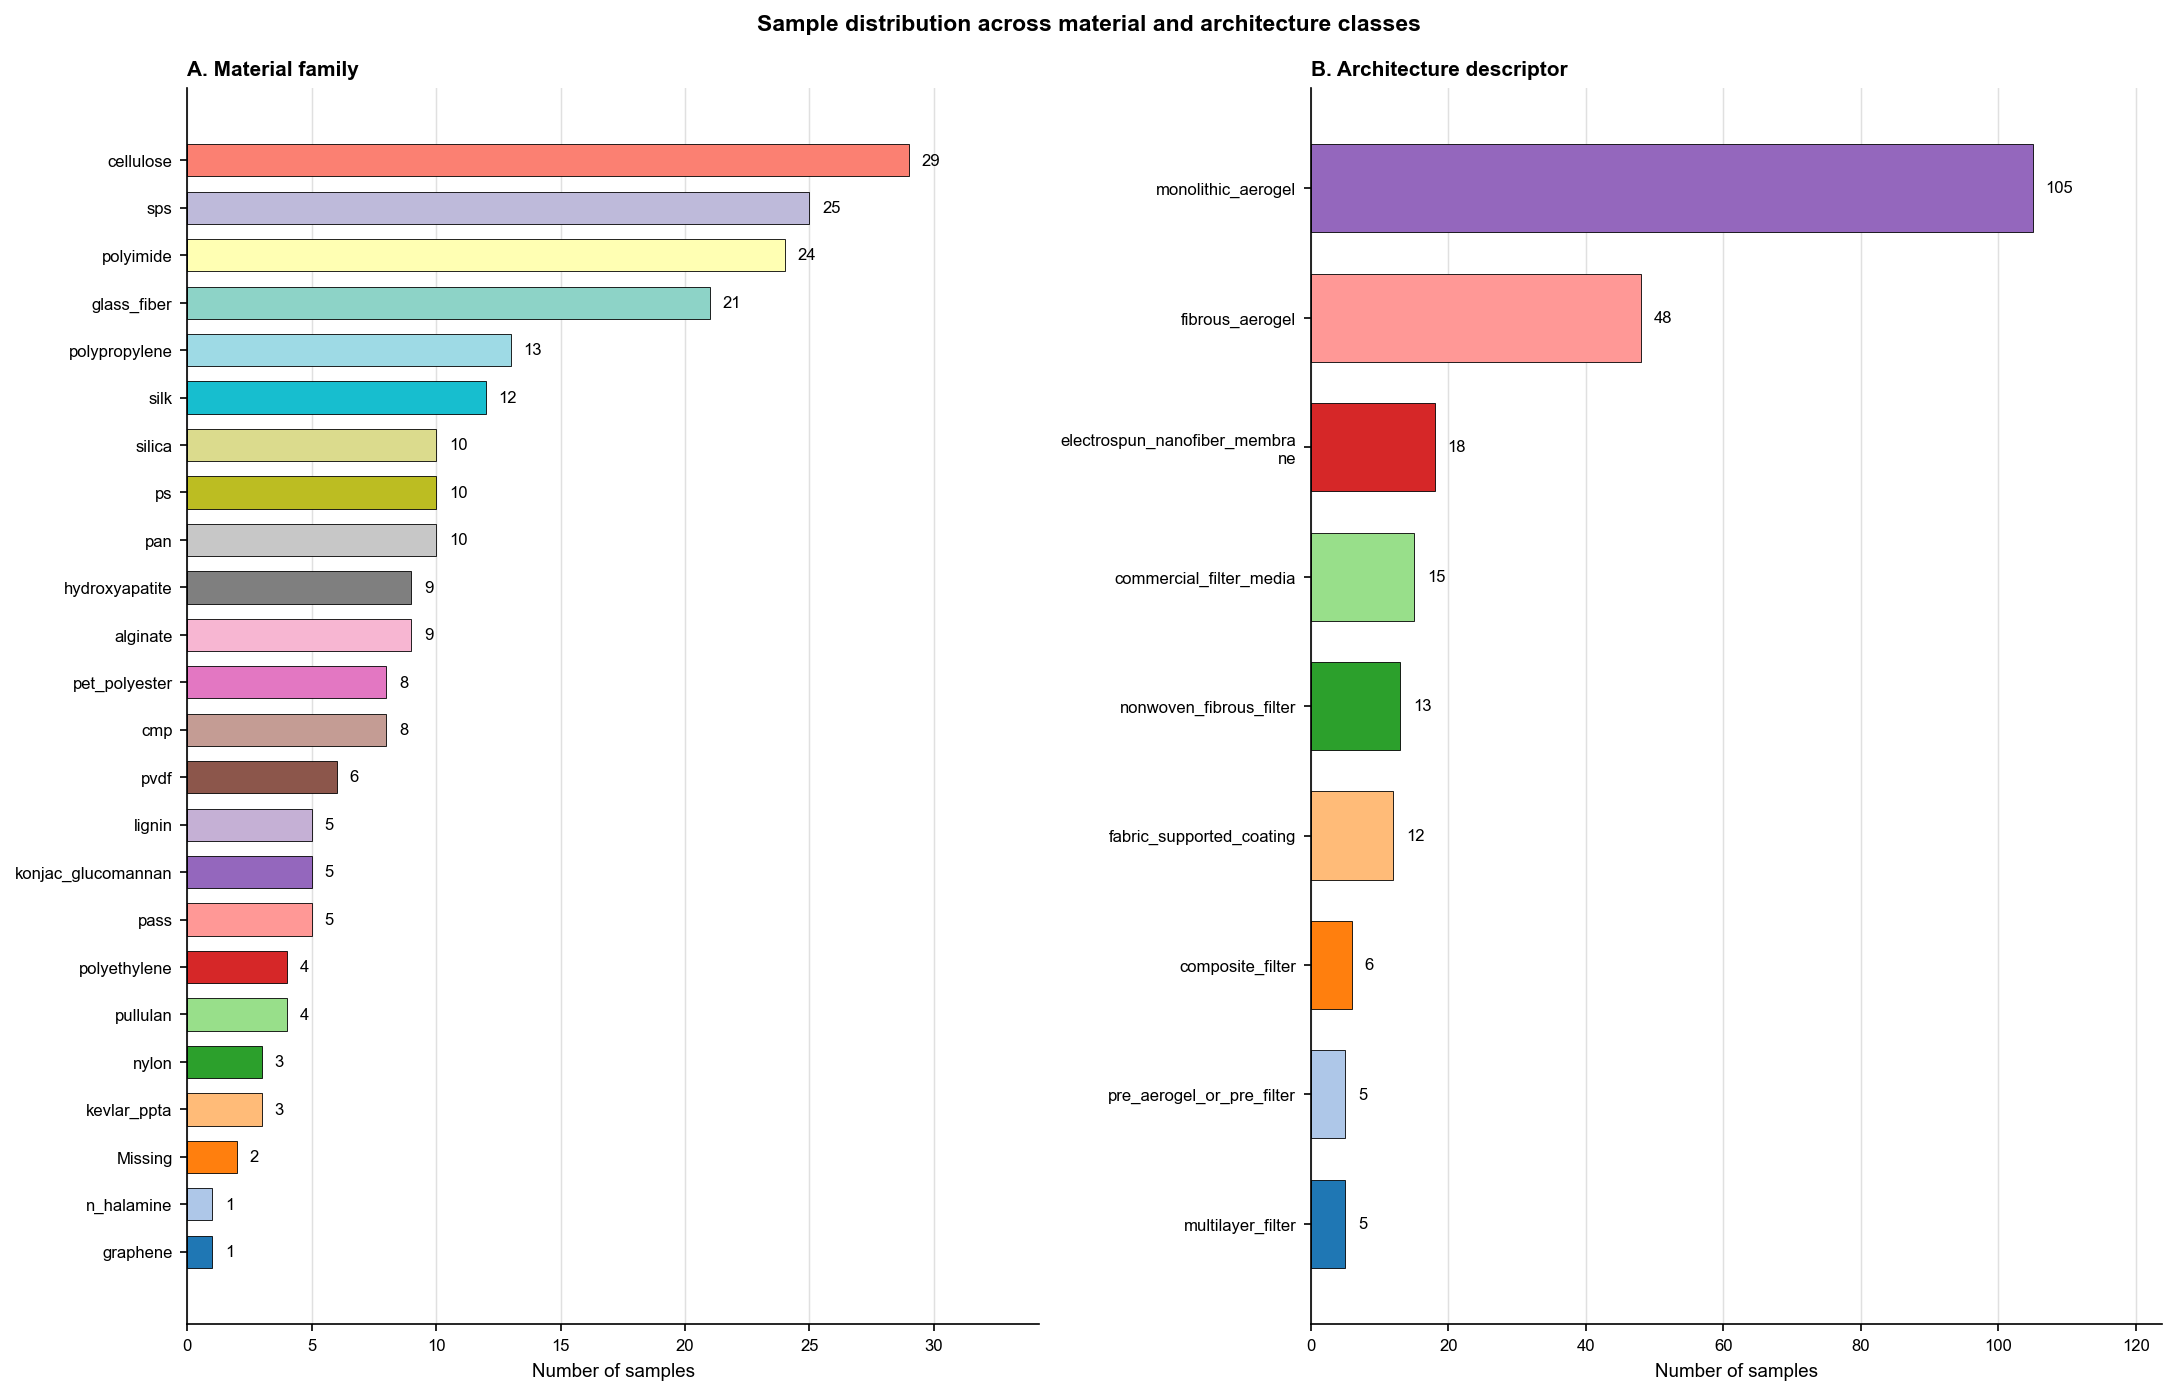

Saved: material_class_counts1.pdf, material_class_counts1.svg, material_class_counts1.png


In [50]:
# Additional figure for material families and architecture types distribution

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from textwrap import fill

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

cols = ["primary_material_family", "architecture_descriptor"]
titles = ["Material family", "Architecture descriptor"]

available = [c for c in cols if c in df.columns]
if not available:
    raise ValueError("None of the requested columns were found in df.")

max_n_categories = max(df[c].fillna("Missing").nunique() for c in available)
fig_height = max(4.2, 0.32 * max_n_categories + 1.2)

fig, axes = plt.subplots(
    1, len(available),
    figsize=(7.2 * len(available), fig_height),
    constrained_layout=True
)

if len(available) == 1:
    axes = [axes]


palette = list(plt.cm.tab20.colors) + list(plt.cm.Set3.colors) + list(plt.cm.Dark2.colors)

for i, (ax, col) in enumerate(zip(axes, available)):
    counts = (
        df[col]
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .sort_values(ascending=True)
    )

    labels = [fill(label, width=28) for label in counts.index]
    values = counts.values
    colors = [palette[j % len(palette)] for j in range(len(counts))]

    bars = ax.barh(
        labels,
        values,
        color=colors,
        edgecolor="black",
        linewidth=0.4,
        height=0.68
    )

    xmax = values.max() * 1.18
    ax.set_xlim(0, xmax)

    for bar, val in zip(bars, values):
        ax.text(
            val + xmax * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{val}",
            va="center",
            ha="left",
            fontsize=8,
            color="black"
        )

    ax.set_title(f"{chr(65+i)}. {titles[cols.index(col)]}", loc="left", fontweight="bold")
    ax.set_xlabel("Number of samples")
    ax.grid(axis="x", color="0.88", linewidth=0.7)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Sample distribution across material and architecture classes",
    fontsize=11,
    fontweight="bold",
    y=1.03
)

fig.savefig("material_class_counts.pdf", bbox_inches="tight")
fig.savefig("material_class_counts.svg", bbox_inches="tight")
fig.savefig("material_class_counts.png", dpi=600, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved: material_class_counts1.pdf, material_class_counts1.svg, material_class_counts1.png")
